# 🧪 Diagnostic Analysis: Deep-Diving into Business Drivers

This notebook implements the second dimension of our analytical framework: **Diagnostic Analysis**.

**Objective:** Investigating *why* things happened, focusing on correlations and root causes.

## 1. Setup and Data Loading

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
plt.style.use('ggplot')

# Load data
df = pd.read_csv('../Amazon.csv')
success_orders = df[df['OrderStatus'].isin(['Delivered', 'Shipped'])]

## 2. Correlation Study: Discount vs. Sales Volume
Does higher discount lead to higher sales quantity?

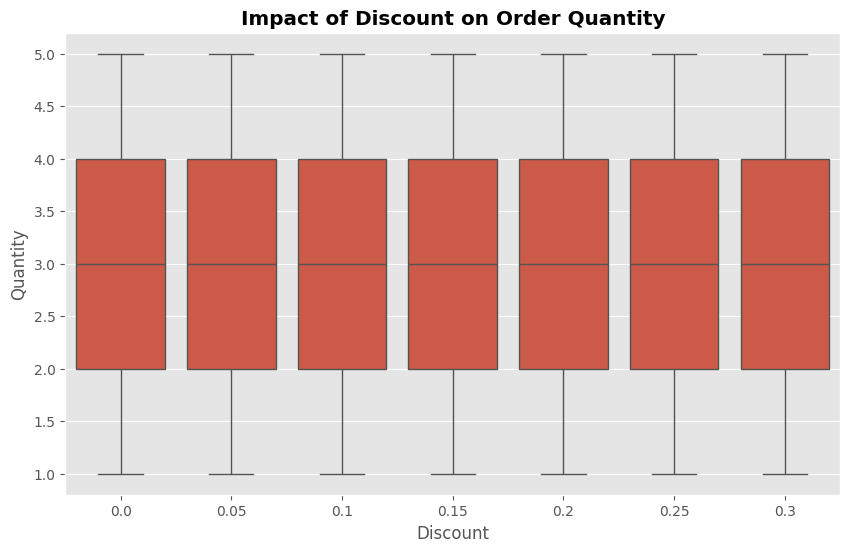

Correlation between Discount and Quantity: -0.0001


In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Discount', y='Quantity', data=success_orders)
plt.title('Impact of Discount on Order Quantity', fontweight='bold')
plt.show()

correlation = success_orders['Discount'].corr(success_orders['Quantity'])
print(f"Correlation between Discount and Quantity: {correlation:.4f}")

## 3. Investigating Return Rates by Category
Which categories are most prone to returns?

C:\Users\shame\AppData\Local\Temp\ipykernel_18620\1301831698.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return_stats = df.groupby('Category').apply(lambda x: (x['OrderStatus'] == 'Returned').mean() * 100).sort_values(ascending=False)


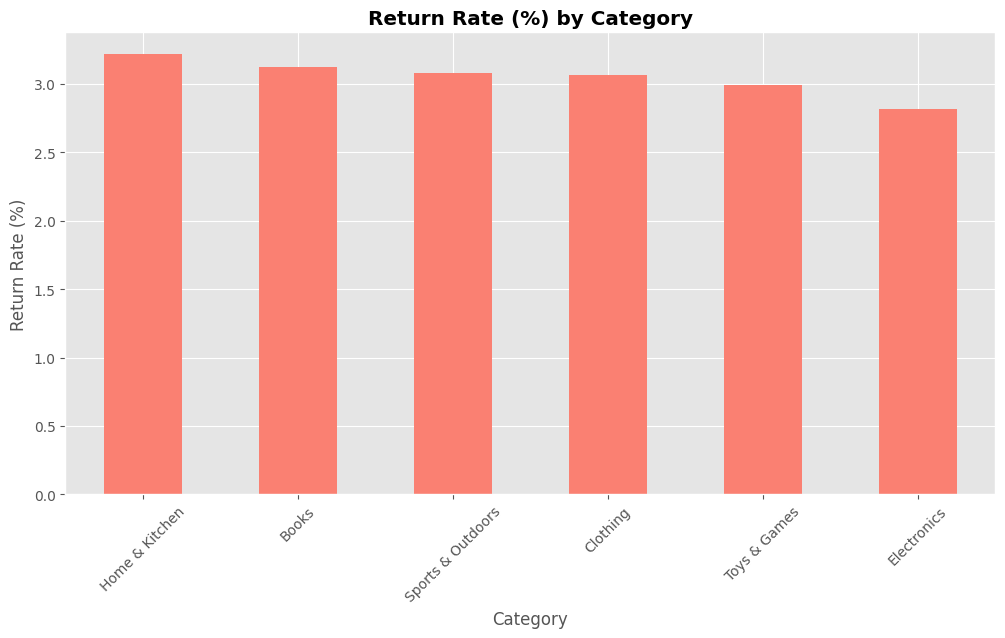

In [9]:
return_stats = df.groupby('Category').apply(lambda x: (x['OrderStatus'] == 'Returned').mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
return_stats.plot(kind='bar', color='salmon')
plt.title('Return Rate (%) by Category', fontweight='bold')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=45)
plt.show()

## 4. Shipping Cost Impact by Region
Do certain states or countries have significantly higher shipping costs?

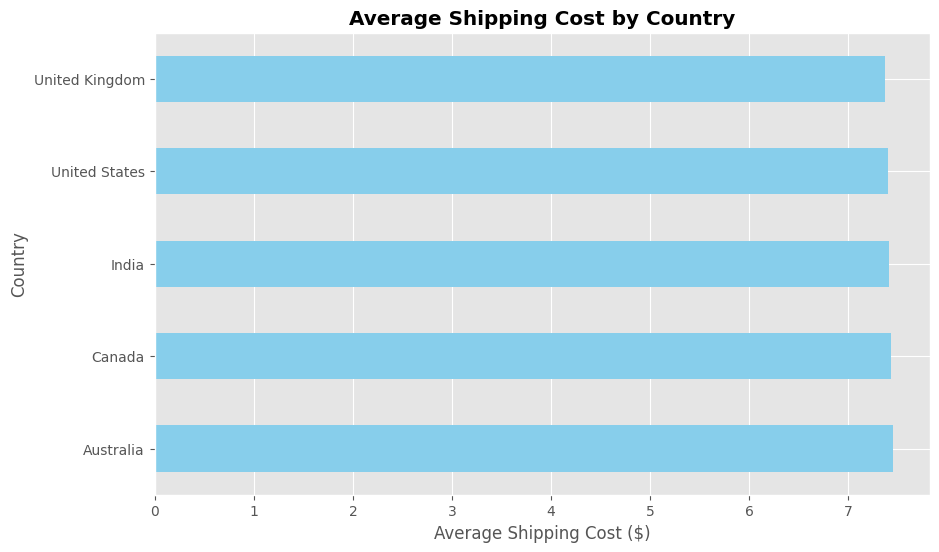

In [10]:
avg_shipping = success_orders.groupby('Country')['ShippingCost'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
avg_shipping.plot(kind='barh', color='skyblue')
plt.title('Average Shipping Cost by Country', fontweight='bold')
plt.xlabel('Average Shipping Cost ($)')
plt.show()